In [6]:
import os
import pandas as pd
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind, ranksums
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import EpiClockNBL.util as nbl_util
nbl_consts = nbl_util.consts

proj_dir = os.path.join(nbl_consts['official_indir'], 'TARGET')

figure_outdir = os.path.join(nbl_consts['repo_dir'], 'figures_revision')
os.makedirs(figure_outdir, exist_ok=True)

In [7]:
clinical = pd.read_table(os.path.join(proj_dir, 'clinical.processed.withAges.tsv')).set_index('submitter_id')

beta_values_Clock = pd.read_table(
    os.path.join(nbl_consts['official_indir'], 'TARGET', 'NBL.methyl.antiNonIterClustNotStuck_sites.tsv'),
    index_col=0)

# Fill NaN values with mean of the tumor's beta values
beta_values_Clock_NaN_filled = beta_values_Clock.copy()
beta_values_Clock_NaN_filled = beta_values_Clock_NaN_filled[clinical['sampleID']]
for tum in beta_values_Clock_NaN_filled.columns:
    beta_values_Clock_NaN_filled[tum] = beta_values_Clock_NaN_filled[tum].fillna(
        beta_values_Clock_NaN_filled[tum].mean()
    )

In [8]:
pca = PCA(n_components=2, random_state=0)
X = beta_values_Clock_NaN_filled.T
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'], index=X.index)
clinical = clinical.merge(pca_df, left_on='sampleID', right_index=True, validate="one_to_one", how="inner")

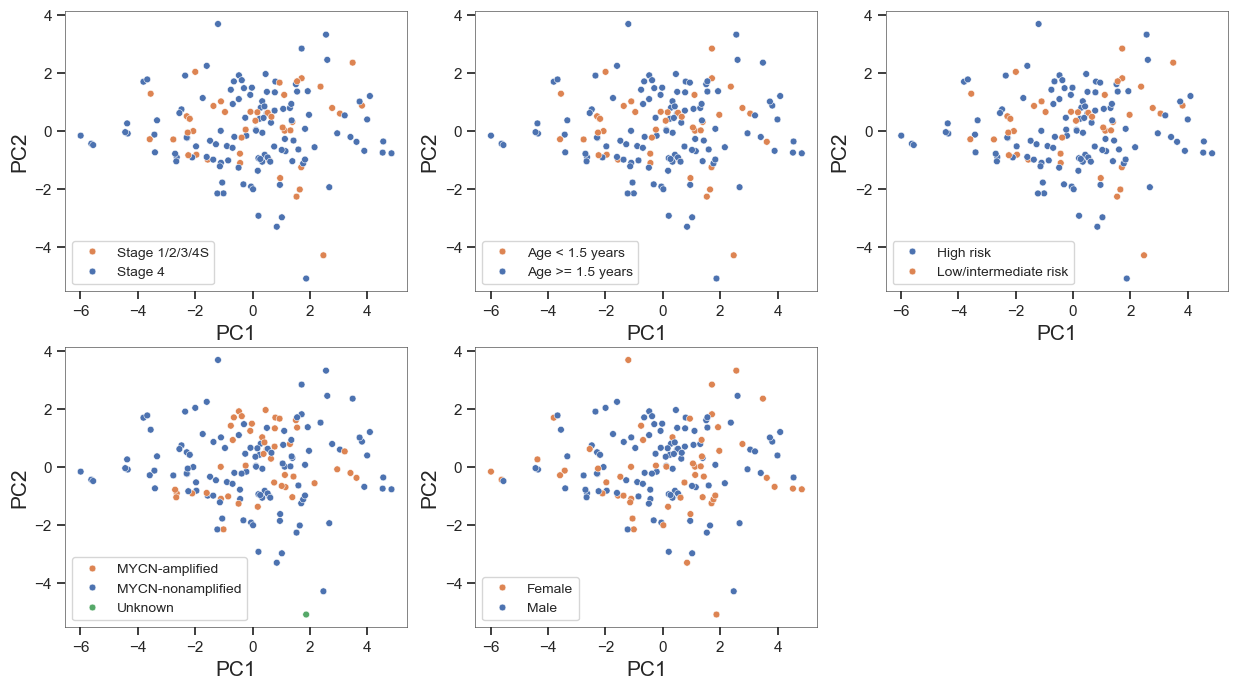

In [9]:
## Configure graph
sf = nbl_consts['sf']
figsize = np.array([5, 4])
sns.set(rc={"savefig.bbox":'tight', 'axes.linewidth':sf}, font_scale=1, style='ticks')

cat_vars = ['Stage grouped', 'Age >= 1.5', 'Risk grouped', 'MYCN status', 'sex_at_birth']

ncol = 3
nrow = ceil(len(cat_vars) / ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=figsize * [ncol, nrow])

clinical['sex_at_birth'] = clinical['sex_at_birth'].str.capitalize()

for i, catv in enumerate(cat_vars):
    row, col = divmod(i, ncol)
    ax = axes[row, col]
    clinical[catv] = clinical[catv].fillna('Unknown')

    sns.scatterplot(
        ax=ax,
        data=clinical,
        x='PC1', y='PC2',
        hue=catv,
        s=nbl_consts['s'] * 1.2 * sf
    )
    ax.get_legend().set_title(None)
    handles, labels = ax.get_legend_handles_labels()
    handles, labels = zip(*sorted(zip(handles, labels), key=lambda x: x[1]))
    ax.legend(handles, labels, fontsize=nbl_consts['labelfontsize'] * sf, loc="lower left")

    ax.set_xlabel(ax.get_xlabel(), fontsize=nbl_consts['labelfontsize'] * 1.5 * sf)
    ax.set_ylabel(ax.get_ylabel(), fontsize=nbl_consts['labelfontsize'] * 1.5 * sf)

axes[-1, -1].axis("off")

fig.savefig(os.path.join(figure_outdir, 'Sensitivity-Analysis-PCA.svg'), format='svg', pad_inches=0.1)

In [10]:
for catv in cat_vars:
    print()
    print(catv)
    print()

    uniq_vals = clinical[catv].value_counts().sort_values(ascending=False).index[:2].values
    print(uniq_vals)

    PC1_pvalue = ttest_ind(
        clinical.loc[clinical[catv] == uniq_vals[0], 'PC1'],
        clinical.loc[clinical[catv] == uniq_vals[1], 'PC1']
        ).pvalue
    PC2_pvalue = ttest_ind(
        clinical.loc[clinical[catv] == uniq_vals[0], 'PC2'],
        clinical.loc[clinical[catv] == uniq_vals[1], 'PC2']
        ).pvalue
    
    print(f'PC-1: P = {PC1_pvalue:.2f}')
    print(f'PC-2: P = {PC2_pvalue:.2f}')


Stage grouped

['Stage 4' 'Stage 1/2/3/4S']
PC-1: P = 0.84
PC-2: P = 0.53

Age >= 1.5

['Age >= 1.5 years' 'Age < 1.5 years']
PC-1: P = 0.99
PC-2: P = 0.87

Risk grouped

['High risk' 'Low/intermediate risk']
PC-1: P = 0.65
PC-2: P = 0.39

MYCN status

['MYCN-nonamplified' 'MYCN-amplified']
PC-1: P = 0.25
PC-2: P = 0.31

sex_at_birth

['Male' 'Female']
PC-1: P = 0.72
PC-2: P = 0.33
